In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from joblib import parallel_backend

import mlflow
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics

from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE
from chesswinnerprediction.baseline.utils import (
    setup_mlflow,
    get_class_weights,
    get_worst_params_df,
    estimate_baseline_model,
    load_train_valid_test,
)

## Set the MLFlow tracking URI and experiment

In [3]:
setup_mlflow(experiment_name="Decision Tree", sklearn_autolog_disable=False)

## Load the data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

class_weight = get_class_weights(y_train)

## Apply the Decision Tree Classifier

In [5]:
random_forest_params = {
    "max_depth": [10, 11, 12],
    "max_features": [None, 0.5, "sqrt"],
    "min_samples_split": [8e-5, 1e-4, 4e-4, 8e-4, 1e-3, 4e-3],
    "min_samples_leaf": [8e-5, 1e-4, 4e-4, 8e-4, 1e-3, 4e-3, 8e-3],
    "min_impurity_decrease": [1e-6, 4e-6, 8e-6, 1e-5, 4e-5],
    "min_weight_fraction_leaf": [0.0, 1e-6, 4e-6],
    "ccp_alpha": [0.0, 1e-6, 4e-6, 8e-6, 1e-5],
    "max_leaf_nodes": [None] + [30 * i for i in range(3, 6)],
}

In [11]:
tree_model = DecisionTreeClassifier(
    class_weight=class_weight, random_state=BASELINE_RANDOM_STATE
)

random_search = RandomizedSearchCV(
    estimator=tree_model,
    param_distributions=random_forest_params,
    n_iter=56,
    cv=5,
    verbose=3,
    random_state=BASELINE_RANDOM_STATE,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    refit=True,
)

In [ ]:
with mlflow.start_run(run_name="random_search") as run:
    random_search_run_id = run.info.run_id
    mlflow.log_param("predict_draws", True)

    with parallel_backend("multiprocessing"):
        random_search.fit(X_train, y_train)

In [13]:
print(f"Best Score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

Best Score: 0.4585198305578995
Best Parameters: {'min_weight_fraction_leaf': 4e-06, 'min_samples_split': 0.001, 'min_samples_leaf': 8e-05, 'min_impurity_decrease': 4e-06, 'max_leaf_nodes': 90, 'max_features': 0.5, 'max_depth': 12, 'ccp_alpha': 1e-06}


In [14]:
get_worst_params_df(random_search.cv_results_).head(5)

,,,,,,,,mean_test_score
param_min_weight_fraction_leaf,param_min_samples_split,param_min_samples_leaf,param_min_impurity_decrease,param_max_leaf_nodes,param_max_features,param_max_depth,param_ccp_alpha,
0.000001,0.00008,0.0008,0.000040,150,sqrt,12,0.000004,0.448623
0.000004,0.00400,0.0001,0.000010,150,sqrt,11,0.000004,0.448989
0.000000,0.00080,0.0008,0.000010,120,sqrt,12,0.000004,0.449614
0.000004,0.00080,0.0010,0.000040,120,sqrt,12,0.000010,0.451012
0.000001,0.00040,0.0001,0.000001,150,sqrt,12,0.000004,0.451016


## Apply the best model

Log Loss on test data: 1.031
Balanced Accuracy on test data: 45.21%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.59      0.43      0.50     75369              0.58      0.43      0.50      4491
         1-0       0.61      0.40      0.48     78653              0.61      0.40      0.49      4790
     1/2-1/2       0.05      0.61      0.09      4115              0.04      0.52      0.08       245
    accuracy                           0.42    158137                                  0.42      9526
   macro avg       0.42      0.48      0.36    158137              0.41      0.45      0.35      9526
weighted avg       0.58      0.42      0.48    158137              0.58      0.42      0.48      9526
       


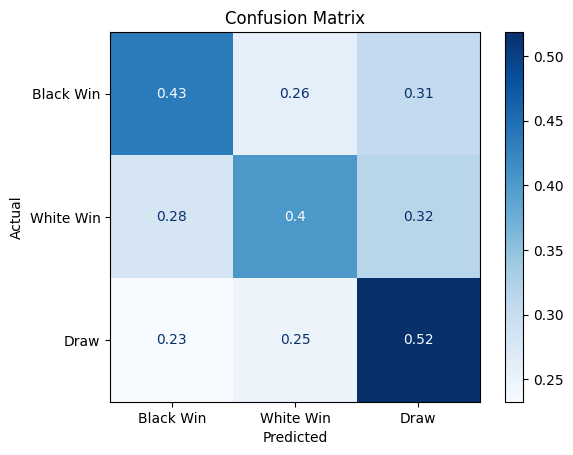

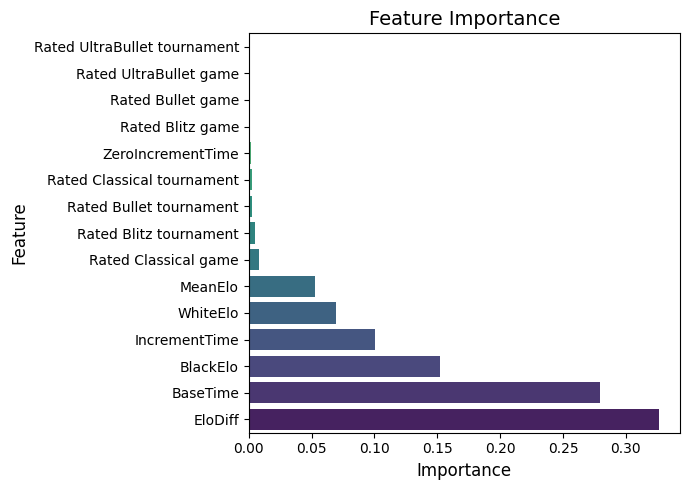

In [15]:
with mlflow.start_run(run_id=random_search_run_id):
    best_tree_clf = random_search.best_estimator_
    best_tree_clf = best_tree_clf.fit(X_train, y_train)

    balanced_accuracy = metrics.balanced_accuracy_score(
        y_test, best_tree_clf.predict(X_test)
    )
    mlflow.log_metric("balanced_accuracy", balanced_accuracy)

    feature_importance = [best_tree_clf.feature_importances_]
    estimate_baseline_model(
        best_tree_clf, feature_importance, X_train, y_train, X_valid, y_valid
    )

## Summary

This is a good result for the Decision Tree, with a balanced accuracy of 45.21%. The next step is to explore ensemble methods.  
As you can see, the draw recall is 0.61 on the training data and 0.52 on the test data, indicating that the model has a better understanding of the data compared to Logistic Regression, which had the same recall with both training and test draws.